# Labour Force Data
Labour force status for adults with disabilities by disability type: https://open.canada.ca/data/en/dataset/92aeb8dc-c7ca-4f44-81df-fdaf289d23fd 

In [2]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Load data

labour_force = pd.read_csv("../data/raw/labour_force_with_disabilities/labourforcewithdisabilities.csv")
labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Total labour force,Number,223,units,0,v91886462,1.1.1.1.1.1,2338240.0,NaN,NaN,NaN,0
1,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Employed,Number,223,units,0,v91886463,1.1.1.1.1.2,1026910.0,NaN,NaN,NaN,0
2,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Unemployed,Number,223,units,0,v91886464,1.1.1.1.1.3,137450.0,NaN,NaN,NaN,0
3,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Not in labour force,Number,223,units,0,v91886465,1.1.1.1.1.4,1007660.0,NaN,NaN,NaN,0
4,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Participation rate,Percent,239,units,0,v91886466,1.1.1.1.1.5,53.6,NaN,NaN,NaN,1


In [3]:
labour_force.tail()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
151195,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized participation rate,Percent,239,units,0,v92037657,14.3.6.12.5.6,NaN,F,NaN,NaN,1
151196,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Employment Rate,Percent,239,units,0,v92037658,14.3.6.12.5.7,NaN,F,NaN,NaN,1
151197,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized employment rate,Percent,239,units,0,v92037659,14.3.6.12.5.8,NaN,F,NaN,NaN,1
151198,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Unemployment rate,Percent,239,units,0,v92037660,14.3.6.12.5.9,NaN,F,NaN,NaN,1
151199,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized unemployment rate,Percent,239,units,0,v92037661,14.3.6.12.5.10,NaN,F,NaN,NaN,1


## EDA (on raw data)

In [4]:
labour_force.shape

(151200, 19)

In [5]:
labour_force.info()

<class 'pandas.DataFrame'>
RangeIndex: 151200 entries, 0 to 151199
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   REF_DATE             151200 non-null  int64  
 1   GEO                  151200 non-null  str    
 2   DGUID                151200 non-null  str    
 3   Sex                  151200 non-null  str    
 4   Age group            151200 non-null  str    
 5   Disability type      151200 non-null  str    
 6   Global Severity      151200 non-null  str    
 7   Labour force status  151200 non-null  str    
 8   UOM                  151200 non-null  str    
 9   UOM_ID               151200 non-null  int64  
 10  SCALAR_FACTOR        151200 non-null  str    
 11  SCALAR_ID            151200 non-null  int64  
 12  VECTOR               151200 non-null  str    
 13  COORDINATE           151200 non-null  str    
 14  VALUE                34597 non-null   float64
 15  STATUS               136535 

In [6]:
labour_force['Sex'].value_counts()

Sex
Both sexes    50400
Males         50400
Females       50400
Name: count, dtype: int64

In [7]:
labour_force.groupby('Sex')['VALUE'].sum().reset_index()

,Sex,VALUE
0,Both sexes,142140711.5
1,Females,73622904.4
2,Males,60797599.0


In [8]:
142140711.5 - (60797599.0+73622904.4)

7720208.099999994

In [9]:
labour_force['Age group'].value_counts()

Age group
Total, 15 to 64 years    25200
15 to 24 years           25200
25 to 34 years           25200
35 to 44 years           25200
45 to 54 years           25200
55 to 64 years           25200
Name: count, dtype: int64

In [10]:
labour_force['Global Severity'].value_counts()

Global Severity
Total population, severity of disability    30240
Mild                                        30240
Moderate                                    30240
Severe                                      30240
Very Severe                                 30240
Name: count, dtype: int64

In [11]:
labour_force['Disability type'].value_counts()

Disability type
All disability types           12600
Seeing                         12600
Hearing                        12600
Mobility                       12600
Flexibility                    12600
Dexterity                      12600
Pain                           12600
Learning                       12600
Memory                         12600
Developmental                  12600
Mental and/or psychological    12600
Unknown disability type        12600
Name: count, dtype: int64

In [12]:
labour_force['Labour force status'].value_counts()

Labour force status
Total labour force                     15120
Employed                               15120
Unemployed                             15120
Not in labour force                    15120
Participation rate                     15120
Age standardized participation rate    15120
Employment Rate                        15120
Age standardized employment rate       15120
Unemployment rate                      15120
Age standardized unemployment rate     15120
Name: count, dtype: int64

In [13]:
labour_force['UOM'].value_counts()

UOM
Percent    90720
Number     60480
Name: count, dtype: int64

In [14]:
# redundant because it contains the same info as labour_force['UOM']
labour_force['UOM_ID'].value_counts()

UOM_ID
239    90720
223    60480
Name: count, dtype: int64

In [15]:
# holds no useful info
labour_force['SCALAR_FACTOR'].value_counts()

SCALAR_FACTOR
units     151200
Name: count, dtype: int64

In [16]:
# holds no useful info
labour_force['SCALAR_ID'].value_counts()

SCALAR_ID
0    151200
Name: count, dtype: int64

In [17]:
# holds no useful info
labour_force['VECTOR'].value_counts()

VECTOR
v91886462    1
v91886463    1
v91886464    1
v91886465    1
v91886466    1
            ..
v92037657    1
v92037658    1
v92037659    1
v92037660    1
v92037661    1
Name: count, Length: 151200, dtype: int64

In [18]:
# holds no useful info
labour_force['COORDINATE'].value_counts()

COORDINATE
1.1.1.1.1.1       1
1.1.1.1.1.2       1
1.1.1.1.1.3       1
1.1.1.1.1.4       1
1.1.1.1.1.5       1
                 ..
14.3.6.12.5.6     1
14.3.6.12.5.7     1
14.3.6.12.5.8     1
14.3.6.12.5.9     1
14.3.6.12.5.10    1
Name: count, Length: 151200, dtype: int64

In [19]:
# Symbol legend: E use with caution, F too unreliable to be published
labour_force['STATUS'].value_counts()

STATUS
F    116603
E     19932
Name: count, dtype: int64

In [20]:
# holds no useful info
labour_force['DECIMALS'].value_counts()

DECIMALS
1    90720
0    60480
Name: count, dtype: int64

In [21]:
# 2. Condition 1: STATUS is 'F' but VALUE is NOT missing (not NaN)
f_but_has_value = labour_force[(labour_force['STATUS'] == 'F') & (labour_force['VALUE'].notnull())]

# 3. Condition 2: VALUE is missing (NaN) but STATUS is NOT 'F'
nan_but_not_f = labour_force[labour_force['VALUE'].isnull() & (labour_force['STATUS'] != 'F')]

# 4. Print individual condition results
print(f"Rows where STATUS == 'F' but VALUE is present: {len(f_but_has_value)}")
print(f"Rows where VALUE is NaN but STATUS != 'F':     {len(nan_but_not_f)}")

# 5. Print aggregate counts for full verification
print("\n--- Aggregate Count Check ---")
print(f"Total rows in dataset:             {len(labour_force):,}")
print(f"Total rows with STATUS == 'F':      {(labour_force['STATUS'] == 'F').sum():,}")
print(f"Total rows with VALUE as NaN:      {labour_force['VALUE'].isnull().sum():,}")

Rows where STATUS == 'F' but VALUE is present: 0
Rows where VALUE is NaN but STATUS != 'F':     0

--- Aggregate Count Check ---
Total rows in dataset:             151,200
Total rows with STATUS == 'F':      116,603
Total rows with VALUE as NaN:      116,603


In [22]:
# Look at the unmasked dataset to check suppression rates (nan for 'VALUE' col or 'F' for 'STATUS' col) across categories
features_to_check = ['GEO', 'Sex', 'Age group', 'Disability type', 'Global Severity']

for col in features_to_check:
    print(f"--- Suppression Rate by {col} ---")
    # Calculate percentage of rows with status 'F' or null values per category
    sparsity = labour_force.groupby(col)['VALUE'].apply(lambda x: (x.isnull()).mean() * 100)
    print(sparsity.sort_values(ascending=False))
    print("\n")

--- Suppression Rate by GEO ---
GEO
Nunavut                      94.490741
Northwest Territories        92.879630
Yukon                        92.620370
Prince Edward Island         83.694444
Newfoundland and Labrador    83.444444
New Brunswick                77.537037
Quebec                       77.250000
Ontario                      74.407407
Nova Scotia                  74.175926
Saskatchewan                 73.685185
British Columbia             73.361111
Alberta                      71.842593
Manitoba                     70.861111
Canada                       39.407407
Name: VALUE, dtype: float64


--- Suppression Rate by Sex ---
Sex
Males         81.626984
Females       79.960317
Both sexes    69.767857
Name: VALUE, dtype: float64


--- Suppression Rate by Age group ---
Age group
25 to 34 years           87.523810
15 to 24 years           82.607143
45 to 54 years           80.849206
35 to 44 years           80.067460
55 to 64 years           79.551587
Total, 15 to 64 years    52

## Data Cleaning
### Filter out NaNs and exclude average values

In [23]:
filter_labour_force = labour_force[
    (labour_force['VALUE'].notnull()) &                                              # Surpressed data (STATUS == F)
    (labour_force['GEO'] != 'Canada') &                                              # Exclude national average
    (labour_force['Sex'] != 'Both sexes') &                                          # Exclude gender average
    (labour_force['Age group'] != 'Total, 15 to 64 years') &                         # Exclude age average
    (labour_force['Global Severity'] != 'Total population, severity of disability')  # Exclude severity average
].copy()

print(f"Macro subset rows available: {len(filter_labour_force)}")

Macro subset rows available: 4343


In [24]:
filter_labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
15010,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Total labour force,Number,223,units,0,v91901472,2.2.2.1.2.1,650.0,E,NaN,NaN,0
15011,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Employed,Number,223,units,0,v91901473,2.2.2.1.2.2,150.0,E,NaN,NaN,0
15013,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Not in labour force,Number,223,units,0,v91901475,2.2.2.1.2.4,440.0,E,NaN,NaN,0
15014,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Participation rate,Percent,239,units,0,v91901476,2.2.2.1.2.5,30.2,E,NaN,NaN,1
15015,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,Percent,239,units,0,v91901477,2.2.2.1.2.6,29.4,E,NaN,NaN,1


In [25]:
e_status = sum(filter_labour_force['STATUS'] == 'E')
print(e_status, e_status/len(filter_labour_force))

3286 0.7566198480313148


**Note**: 3286 out of 4343 rows (over 75%) of the data are labelled E (use with caution). We will drop the status label and note that our results should be interpreted with caution.

### Drop unnecessary columns

In [26]:
columns_to_drop = ['REF_DATE', 
                   'DGUID',
                   'UOM',
                   'UOM_ID', 
                   'SCALAR_FACTOR', 
                   'SCALAR_ID', 
                   'VECTOR', 
                   'COORDINATE', 
                   'SYMBOL', 
                   'TERMINATED', 
                   'DECIMALS',
                   'STATUS']

clean_labour_force = filter_labour_force.drop(columns=columns_to_drop)

In [27]:
clean_labour_force.info()

<class 'pandas.DataFrame'>
Index: 4343 entries, 15010 to 150630
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GEO                  4343 non-null   str    
 1   Sex                  4343 non-null   str    
 2   Age group            4343 non-null   str    
 3   Disability type      4343 non-null   str    
 4   Global Severity      4343 non-null   str    
 5   Labour force status  4343 non-null   str    
 6   VALUE                4343 non-null   float64
dtypes: float64(1), str(6)
memory usage: 271.4 KB


In [28]:
clean_labour_force.groupby('Sex')['VALUE'].sum().reset_index()

,Sex,VALUE
0,Females,6106063.1
1,Males,4393674.9


In [29]:
clean_labour_force.groupby('Global Severity')['VALUE'].sum().reset_index()

,Global Severity,VALUE
0,Mild,1943096.8
1,Moderate,1347943.4
2,Severe,2253173.2
3,Very Severe,4955524.6


In [30]:
clean_labour_force.groupby('Labour force status')['VALUE'].sum().reset_index()

,Labour force status,VALUE
0,Age standardized employment rate,28600.7
1,Age standardized participation rate,40674.3
2,Age standardized unemployment rate,131.7
3,Employed,1127740.0
4,Employment Rate,28665.4
5,Not in labour force,2157550.0
6,Participation rate,40663.9
7,Total labour force,7075460.0
8,Unemployed,120.0
9,Unemployment rate,132.0


In [31]:
clean_labour_force.groupby('Disability type')['VALUE'].sum().reset_index()

,Disability type,VALUE
0,All disability types,3683642.5
1,Developmental,45930.0
2,Dexterity,433570.0
3,Flexibility,1421645.1
4,Hearing,71533.4
5,Learning,304751.8
6,Memory,198610.0
7,Mental and/or psychological,614689.9
8,Mobility,1240494.4
9,Pain,2334430.9


### Renaming columns
Changing the column names to a more interpretable version and lowercase:

In [32]:
clean_labour_force.columns

Index(['GEO', 'Sex', 'Age group', 'Disability type', 'Global Severity',
       'Labour force status', 'VALUE'],
      dtype='str')

In [33]:
column_names = {
    'GEO' : 'geography',
    'Sex' : 'sex',
    'Age group' : 'age_group',
    'Disability type' : 'disability_type',
    'Global Severity' : 'global_severity',
    'Labour force status' : 'labour_force_status',
    'VALUE' : 'value'
}
clean_labour_force = clean_labour_force.rename(columns = column_names)
clean_labour_force.head()

,geography,sex,age_group,disability_type,global_severity,labour_force_status,value
15010,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Total labour force,650.0
15011,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Employed,150.0
15013,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Not in labour force,440.0
15014,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Participation rate,30.2
15015,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,29.4


In [34]:
clean_labour_force.shape

(4343, 7)

### Save cleaned file

In [35]:
clean_labour_force.to_csv("../data/clean/labourforcewithdisabilities.csv", index=False)

In [36]:
# Validate cleaned data
clean_data = pd.read_csv("../data/clean/labourforcewithdisabilities.csv")

print(f"Final cleaned dataset rows: {(clean_data.shape)}")
clean_data.head()

Final cleaned dataset rows: (4343, 7)


,geography,sex,age_group,disability_type,global_severity,labour_force_status,value
0,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Total labour force,650.0
1,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Employed,150.0
2,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Not in labour force,440.0
3,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Participation rate,30.2
4,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,29.4


# Case Study
## Objective

What are the key drivers of employment for individuals with disabilities?

## Analysis


### 1. Data Cleaning & Processing
- Filter out employment rates
- Convert variable types to factors as required in R

In [8]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
labour_force = pd.read_csv("../data/clean/labourforcewithdisabilities.csv")
labour_force.shape

(4343, 7)

In [5]:
# Extract rates and population weights

# Filter for the target disability category to avoid double-counting
df_all_disabilities = labour_force[labour_force['disability_type'] == 'All disability types']

# Separate the employment rates from the population counts
df_rates = df_all_disabilities[df_all_disabilities['labour_force_status'] == 'Employment Rate'].copy()
# CORRECTED: Use 'Total labour force' to get the numeric headcount for the weight
df_pop = df_all_disabilities[df_all_disabilities['labour_force_status'] == 'Total labour force'].copy()

# Rename the 'value' columns before merging
df_rates = df_rates.rename(columns={'value': 'employment_rate'})
df_pop = df_pop.rename(columns={'value': 'population_weight'})

# Merge to align rates with their respective population weights
merge_cols = ['geography', 'sex', 'age_group', 'global_severity']
model_df = pd.merge(df_rates[merge_cols + ['employment_rate']], 
                    df_pop[merge_cols + ['population_weight']], 
                    on=merge_cols, 
                    how='inner')

# Drop any rows with suppressed or missing data
model_df = model_df.dropna(subset=['employment_rate', 'population_weight'])

model_df

,geography,sex,age_group,global_severity,employment_rate,population_weight
0,Newfoundland and Labrador,Males,15 to 24 years,Mild,23.8,650.0
1,Newfoundland and Labrador,Males,25 to 34 years,Mild,69.2,1070.0
2,Newfoundland and Labrador,Males,35 to 44 years,Mild,74.8,1260.0
3,Newfoundland and Labrador,Males,35 to 44 years,Moderate,43.6,550.0
4,Newfoundland and Labrador,Males,45 to 54 years,Mild,78.1,2800.0
...,...,...,...,...,...,...
211,Yukon,Males,55 to 64 years,Mild,61.5,260.0
212,Yukon,Females,35 to 44 years,Mild,93.3,150.0
213,Yukon,Females,45 to 54 years,Mild,100.0,140.0
214,Yukon,Females,55 to 64 years,Mild,73.3,150.0


### 2. Exploratory Data Analysis

In [39]:
employment_rate['geography'].value_counts()

geography
Manitoba                     80
Saskatchewan                 70
Alberta                      61
British Columbia             48
Nova Scotia                  46
Ontario                      45
New Brunswick                29
Quebec                       29
Prince Edward Island         25
Newfoundland and Labrador    16
Yukon                         5
Nunavut                       1
Name: count, dtype: int64

As we can see above, the amount of information available for each region differs drastically. There is very little information available on the territories: Yukon and Nunavut. 

#### Employment Rates by Different Factors

Before applying predictive modelling or statistical tests, visualizing the raw aggregated metrics provides an intuitive baseline. Since the `disability_type` column contains an overarching "All disability types" category alongside specific impairments (like "Pain" or "Mobility"), we will isolate the "All disability types" subset for this initial EDA to prevent double-counting.  

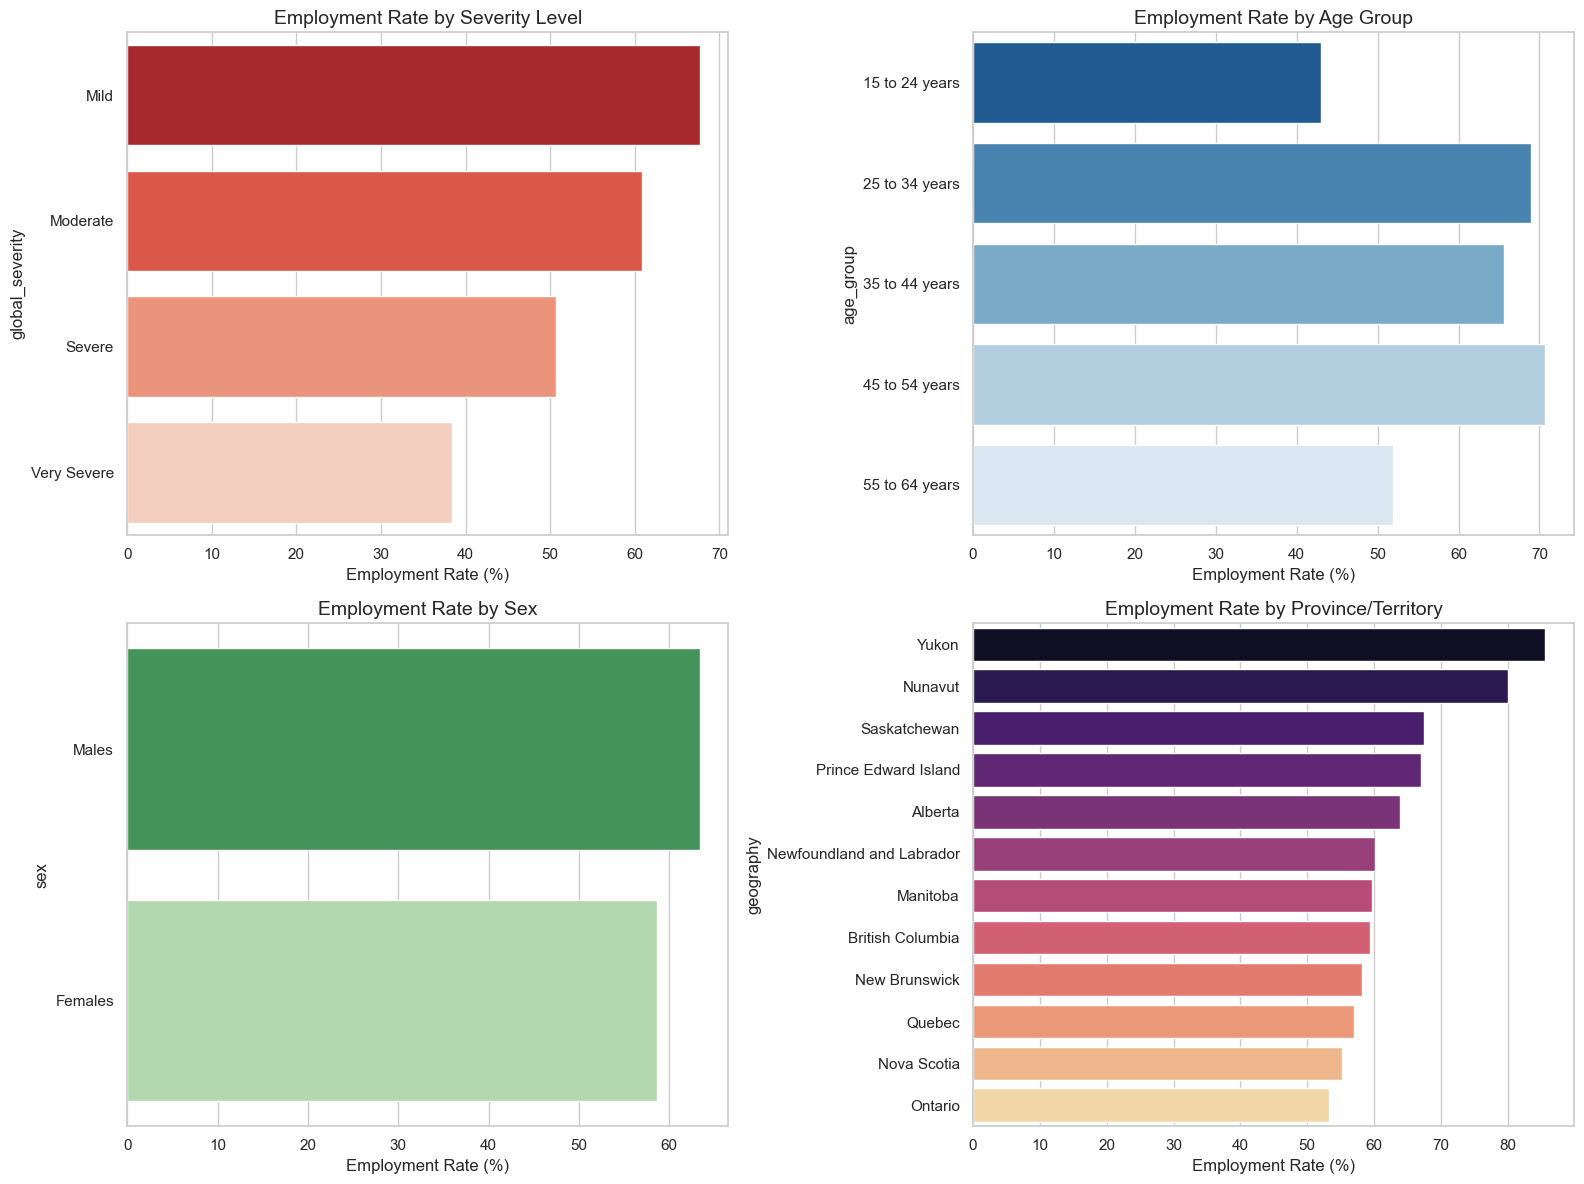

In [40]:
# Focus only on Employment Rate and looking at all disability types 
employment_rate_all_disability_types = employment_rate[employment_rate['disability_type'] == 'All disability types'].copy()

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Severity Driver
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='global_severity', 
    hue='global_severity', 
    ax=axes[0,0], 
    errorbar=None, 
    palette="Reds_r", 
    legend=False
)
axes[0,0].set_title('Employment Rate by Severity Level', fontsize=14)
axes[0,0].set_xlabel('Employment Rate (%)')

# 2. Age Driver
sns.barplot(
    data= employment_rate_all_disability_types, 
    x='value', 
    y='age_group', 
    hue='age_group', 
    ax=axes[0,1], 
    errorbar=None, 
    palette="Blues_r", 
    legend=False
)
axes[0,1].set_title('Employment Rate by Age Group', fontsize=14)
axes[0,1].set_xlabel('Employment Rate (%)')

# 3. Sex Driver
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='sex', 
    hue='sex', 
    ax=axes[1,0], 
    errorbar=None, 
    palette="Greens_r", 
    legend=False
)
axes[1,0].set_title('Employment Rate by Sex', fontsize=14)
axes[1,0].set_xlabel('Employment Rate (%)')

# 4. Location Driver (y-axis sorted by employment rate)
geo_order = (
    employment_rate_all_disability_types.groupby("geography")["value"]
    .mean()
    .sort_values(ascending=False)
    .index
)
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='geography', 
    hue='geography',
    order=geo_order,
    hue_order=geo_order,
    ax=axes[1,1], 
    errorbar=None, 
    palette="magma", 
    legend=False
)
axes[1,1].set_title('Employment Rate by Province/Territory', fontsize=14)
axes[1,1].set_xlabel('Employment Rate (%)')

plt.tight_layout()
plt.show()

The exploratory plots revealed some interesting trends influencing employment:

**Employment by Severity Level**: We can see a negative relationship between disability severity and employment rates. Mild impairments show employment rates near 70%, while Very Severe impairments drop significantly.

**Employment by Age Group**: We can see that employment rates follow a bell curve across age groups. The prime working ages (25-54) see the highest employment rates, whereas youth (15-24) and those nearing retirement (55-64) have much lower employment rates.

**Employment by Sex**: Males show a slightly higher employment rate than females, though the gap appears narrower than the impact of age or severity.

**Employment by Province/Territory**: While Yukon and Nunavut display high rates, their sample sizes are exceptionally small and prone to high variance. Therefore, these insights should be interpreted with caution. 

### 3. Model

To investigate which factors have the most significant impact on employment rates... 

In [6]:
# 2. Prepare the Target Variable
# A Binomial GLM expects the target variable to be a proportion between 0 and 1 rather than a percentage.

# Convert rate to a 0-1 proportion for the Fractional Logit model
model_df['employment_proportion'] = model_df['employment_rate'] / 100.0

In [9]:
# 3. Define Explicit Baselines & Fit the Weighted Model

# Define formula explicitly setting the reference group for each demographic
# The coefficients will show the effect relative to: Ontario, Males, 25-34 years, Mild severity
formula = (
    "employment_proportion ~ "
    "C(geography, Treatment(reference='Ontario')) + "
    "C(sex, Treatment(reference='Males')) + "
    "C(age_group, Treatment(reference='25 to 34 years')) + "
    "C(global_severity, Treatment(reference='Mild'))"
)

# Fit a Generalized Linear Model with Binomial family and population weights
weighted_glm = smf.glm(
    formula=formula, 
    data=model_df, 
    family=sm.families.Binomial(), 
    var_weights=model_df['population_weight']
).fit()

print(weighted_glm.summary())

                   Generalized Linear Model Regression Results                   
Dep. Variable:     employment_proportion   No. Observations:                  216
Model:                               GLM   Df Residuals:                      196
Model Family:                   Binomial   Df Model:                           19
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:            -6.4739e+05
Date:                   Thu, 27 Aug 2026   Deviance:                       84504.
Time:                           14:34:03   Pearson chi2:                 8.02e+04
No. Iterations:                        5   Pseudo R-squ. (CS):              1.000
Covariance Type:               nonrobust                                         
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

Inferential findings from the Weighted Fractional Logit Regression

## Methodological Framework

By implementing a Generalized Linear Model (GLM) with a Binomial family and applying total labour force headcounts as sample weights, the model evaluates the dataset as millions of surveyed individuals rather than 216 equally weighted aggregated rows. This corrects the ecological fallacy and provides the statistical power necessary to validate the exploratory findings with high confidence ($p < 0.001$). Furthermore, the fractional logit format ensures that all modeled employment expectations are mathematically bounded between 0% and 100%.

## Baseline Employment Profile

The model establishes a clear reference point to evaluate demographic impacts. The intercept coefficient ($0.9377$) represents the expected log-odds for this baseline group:

* **Sex:** Male
* **Age:** 25 to 34 years
* **Location:** Ontario
* **Disability Severity:** Mild

Converting this log-odds intercept to a probability ($e^{0.9377} / (1 + e^{0.9377})$) establishes a baseline expected employment rate of **71.8%** for this specific demographic.

## Key Demographic Drivers

Holding all other variables constant, the model isolates the specific impact of individual demographic factors on the log-odds of employment:

* **Disability Severity:** Severity acts as a massive and monotonic barrier to employment. Moving from a Mild disability to Moderate ($-0.4496$), Severe ($-0.9263$), or Very Severe ($-1.5372$) strictly and significantly decreases the likelihood of employment. These represent the largest negative coefficients in the model.
* **Age Dynamics:** The prime working years for individuals with disabilities peak slightly older than the baseline. Adults aged 35 to 44 ($+0.1863$) and 45 to 54 ($+0.1398$) experience statistically higher employment odds than the 25 to 34 cohort. Conversely, youth aged 15 to 24 face the steepest overall penalty in the model ($-1.2410$), while older adults aged 55 to 64 face a substantial drop ($-0.6809$) as they approach retirement.
* **Sex:** Being female is associated with a statistically significant decrease in the log-odds of employment ($-0.1924$) compared to males. While smaller in magnitude than the effects of age or severity, population weighting confirms this gender gap is a systemic driver rather than sample noise.

## Geographic Disparities

Provincial coefficients reveal significant regional variations in employment outcomes relative to Ontario:

* **Higher Employment Odds:** Alberta ($+0.5635$), Saskatchewan ($+0.6344$), and Manitoba ($+0.4699$) demonstrate significantly better employment outcomes for individuals with disabilities compared to the baseline.
* **Lower Employment Odds:** Quebec is the only statistically significant province indicating lower employment odds ($-0.0742$) than Ontario.
* **Data Sparsity Validation:** Nunavut returns a $p$-value of $0.176$, making it the sole statistically insignificant variable in the model. This perfectly validates the exploratory data analysis, confirming that the territory's sample size is too small and volatile to draw reliable inferential conclusions.

The analysis provides a comprehensive view of the systemic barriers in the labour market. 

Background dataset has 216 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=216 when initializing the masker.


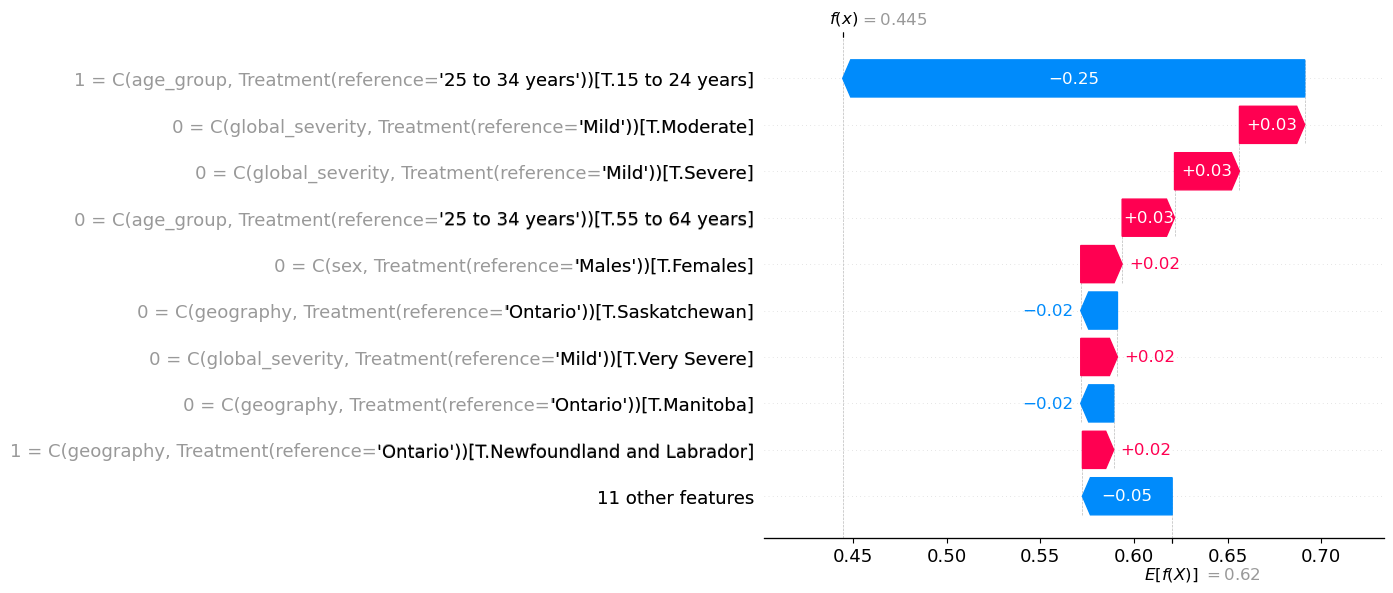

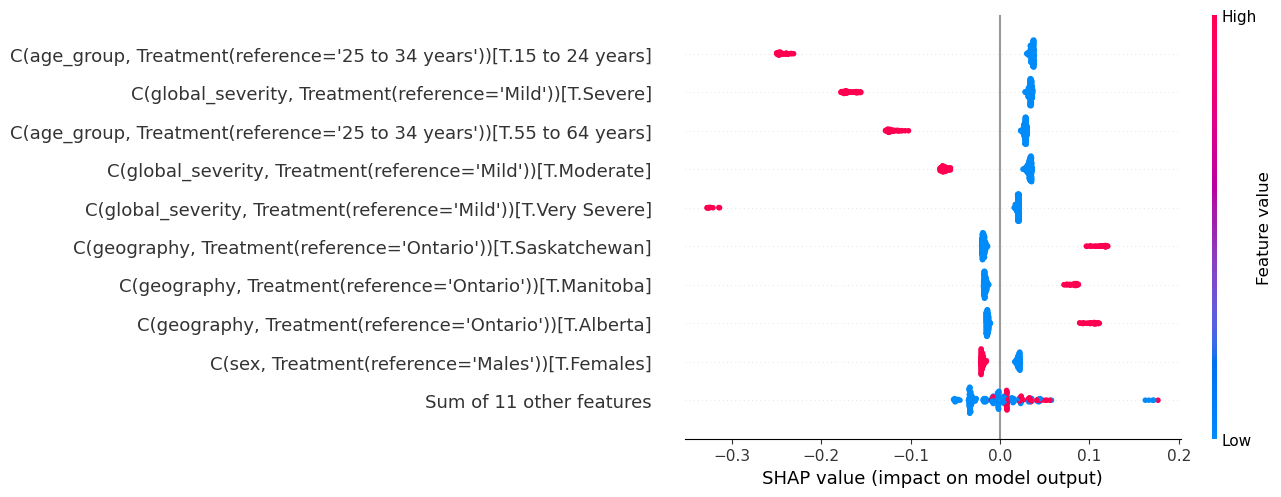

In [14]:
import shap
from patsy import dmatrices

# 1. Recreate the numeric design matrix exactly as statsmodels built it
y_matrix, X_design = dmatrices(formula, model_df, return_type='dataframe')

# 2. Create a wrapper function for predictions
def glm_predict_wrapper(X):
    # transform=False prevents statsmodels from looking for the original string columns
    return weighted_glm.predict(exog=X, transform=False)

# 3. Create the SHAP explainer using the wrapper function and the design matrix
explainer_glm = shap.Explainer(glm_predict_wrapper, X_design)
shap_values_glm = explainer_glm(X_design)

# 4. Visualize a Waterfall plot for the first demographic profile
# This shows how each specific trait pushes their employment probability up or down
shap.plots.waterfall(shap_values_glm[0])

# 5. Generate a standard Beeswarm plot
shap.plots.beeswarm(shap_values_glm)

The SHAP visualizations above translate the GLM's abstract log-odds into clear, probability-based impacts, making the barriers to employment immediately accessible.

**The Waterfall Plot (Micro View: A Specific Profile)**
The top chart breaks down the exact mathematical path for a single demographic group.

* **The Baseline:** The expected employment probability across the entire weighted dataset is **62%** ($E[f(X)] = 0.62$).
* **The Prediction:** This specific demographic group has a predicted employment rate of **44.5%** ($f(x) = 0.445$).
* **The Drivers:** The massive blue bar shows *why* this group is below average: falling into the **15 to 24 years** age bracket drops their expected employment rate by **25 percentage points** ($-0.25$). Small positive corrections are applied because this group does *not* have a Moderate, Severe, or Very Severe disability (indicated by the `0` values), meaning they benefit from the baseline Mild severity.

**The Beeswarm Plot (Macro View: Global Trends)**
The bottom chart ranks the features by their overall impact across all demographic combinations. Because this explainer uses the GLM's predict method, the x-axis directly represents percentage point shifts (e.g., $-0.2$ is a 20% drop in employment probability).

* **The Youth Penalty:** The 15 to 24 age bracket (top row) is the single most disruptive feature. When this feature is "true" (red dots), it drags the employment probability down by 25 to 30 percentage points.
* **The Severity Gradient:** Very Severe, Severe, and Moderate disabilities systematically pull employment probabilities to the left. Very Severe disabilities alone account for an approximate 30 percentage point drop.
* **Geographic Boosts:** Living in Saskatchewan, Manitoba, or Alberta (red dots clustered on the right) provides a distinct 5 to 10 percentage point advantage over the baseline.

The x-axis represents literal percentage points.

In [15]:
import numpy as np

# 1. Extract true values, predicted values, and population weights
y_true = model_df['employment_proportion']
y_pred = weighted_glm.predict()
weights = model_df['population_weight']

# 2. Calculate Weighted RMSE
weighted_mse = np.average((y_true - y_pred)**2, weights=weights)
weighted_rmse = np.sqrt(weighted_mse)

# 3. Calculate Weighted Adjusted R-Squared
# Find the weighted baseline average of the employment rate
y_bar_weighted = np.average(y_true, weights=weights)

# Calculate Weighted Sum of Squares for Residuals (SSR) and Total (SST)
ssr_weighted = np.sum(weights * (y_true - y_pred)**2)
sst_weighted = np.sum(weights * (y_true - y_bar_weighted)**2)

# Calculate Weighted R-Squared
r_squared_weighted = 1 - (ssr_weighted / sst_weighted)

# Apply the adjustment penalty based on degrees of freedom
n = len(y_true)
p = weighted_glm.df_model # Number of predictor variables

adj_r_squared_weighted = 1 - (1 - r_squared_weighted) * ((n - 1) / (n - p - 1))

print(f"Weighted RMSE: {weighted_rmse:.4f}")
print(f"Weighted Adjusted R-squared: {adj_r_squared_weighted:.4f}")

Weighted RMSE: 0.1064
Weighted Adjusted R-squared: 0.6521


A Weighted RMSE of 0.1064 means the model's predicted employment proportions deviate from the actual proportions by an average of about 10.6 percentage points. Given the natural volatility of socio-demographic survey data, a 10.6% error margin is highly respectable. It shows the model captures the primary trends accurately without overfitting to noise.

A Weighted Adjusted R-squared of 0.6521 indicates that the four core features — age, sex, geography, and disability severity — explain roughly 65.2% of the variance in employment rates across the population. In labour economics and social sciences, explaining 65% of the variance is considered a very strong result, especially since human behaviour is influenced by many unmeasured factors like education level, local industry health, and personal choice.

## Discussion

...